# Exploratory Data Analysis (EDA) 

This notebook examines the distribution of VAS-derived migraine
severity and explores associations between physiological,
environmental, lifestyle, and temporal predictors and migraine
severity. Only observations meeting ICHD-3 criteria for migraine
and containing a valid VAS-derived severity label are included.

## 1. Setup and Data Preparation

### 1.1 Project Setup

Configure the project directory so that reusable functions and configuration settings from the `src` folder can be imported into the notebook.

In [1]:
from pathlib import Path
import sys

# The notebook is stored inside THESIS/Notebooks,
# so its parent directory is the project root.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\rebec\Documents\Thesis


In [2]:
Path.cwd()

WindowsPath('c:/Users/rebec/Documents/Thesis/Notebooks')

### 1.2 Import Libraries and Configuration

Import the libraries, project configuration settings, and reusable EDA utility functions required for the analyses in this notebook.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()



from src.config import (
    CLEAN_DATA_FILE,
    TARGET,
    MIGRAINE_FILTER,
    SEVERITY_ORDER,
    PHYSIOLOGICAL_BINARY_FEATURES,
    PHYSIOLOGICAL_ORDINAL_FEATURES,
    ENVIRONMENTAL_BINARY_FEATURES,
    LIFESTYLE_BINARY_FEATURES,
    TEMPORAL_FEATURES,
    WEATHER_FEATURES,
    FEATURE_GROUPS,
    FEATURE_SETS,
    RANDOM_STATE,
)

from src.eda_utils import (
    validate_binary_columns,
    create_binary_prevalence_table,
    plot_binary_prevalence,
    create_ordinal_percentage_table,
)

from src.eda_utils import plot_grouped_binary_prevalence

from src.eda_utils import (
    analyze_binary_associations,
    analyze_categorical_associations,
    add_benjamini_hochberg_correction,
    calculate_phi_matrix
)

### 1.3 Load Cleaned Data

In [4]:
diary = pd.read_csv(CLEAN_DATA_FILE)

print(f"Rows: {diary.shape[0]}")
print(f"Columns: {diary.shape[1]}")

Rows: 4544
Columns: 38


### 1.4 Reapply Categorical Ordering

Reapply the ordered severity categories after loading the cleaned CSV so that Mild, Moderate, and Severe are consistently displayed in their natural order throughout the analysis.

In [5]:
diary[TARGET] = pd.Categorical(
    diary[TARGET],
    categories=SEVERITY_ORDER,
    ordered=True,
)

### 1.5 Create Modeling Dataset

Create the analysis dataset by retaining observations that meet the ICHD-3 criteria for migraine and have a valid VAS-derived severity classification. A copy is created to preserve the original cleaned dataset.

This subset represents the population that will be used for subsequent feature engineering and model development.

**This will be the actual dataset I will train my models on**

In [6]:
model_df = diary.loc[
    (diary[MIGRAINE_FILTER] == 1)
    & diary[TARGET].notna()
].copy()

model_df = model_df.reset_index(drop=True)

print(f"Modeling observations: {model_df.shape[0]}")
print(model_df[TARGET].value_counts().sort_index())

Modeling observations: 302
Severity_VAS
Mild         55
Moderate    138
Severe      109
Name: count, dtype: int64


### 1.6 Validate Reusable Feature Definitions

Before beginning EDA, verify that the feature groups defined in the project configuration are consistent with the modeling dataset.

#### 1.6.1 Confirm every configured feature exists

In [7]:
configured_features = {
    feature
    for feature_list in FEATURE_GROUPS.values()
    for feature in feature_list
}

missing_features = sorted(
    configured_features - set(model_df.columns)
)

if missing_features:
    print("Configured features missing from model_df:")
    for feature in missing_features:
        print(f"  - {feature}")
else:
    print("All configured features were found.")

All configured features were found.


#### 1.6.2 Check whether variables appear in multiple groups

In [8]:
all_grouped_features = [
    feature
    for feature_list in FEATURE_GROUPS.values()
    for feature in feature_list
]

duplicate_assignments = sorted({
    feature
    for feature in all_grouped_features
    if all_grouped_features.count(feature) > 1
})

if duplicate_assignments:
    print("Features assigned to multiple groups:")
    for feature in duplicate_assignments:
        print(f"  - {feature}")
else:
    print("No duplicate feature assignments.")

No duplicate feature assignments.


#### 1.6.3 Validate Binary Feature Encoding

Confirm that configured binary predictors contain only the expected binary values before calculating prevalence and association statistics.

In [9]:
all_binary_features = (
    PHYSIOLOGICAL_BINARY_FEATURES
    + ENVIRONMENTAL_BINARY_FEATURES
    + LIFESTYLE_BINARY_FEATURES
)

binary_problems = validate_binary_columns(
    model_df,
    all_binary_features,
)

if binary_problems:
    binary_problems
else:
    print("All binary features contain only 0 and 1.")

All binary features contain only 0 and 1.


## 2. Modeling Dataset Overview

Explore the distribution of migraine severity and examine how physiological, environmental, lifestyle, and temporal predictors vary across severity levels.

### 2.1 Migraine Severity Distribution

Examine the number and percentage of migraine episodes classified as Mild, Moderate, or Severe based on VAS scores. This assessment identifies potential class imbalance that should be considered during model development and evaluation.

In [10]:
severity_counts = (
    model_df[TARGET]
    .value_counts()
    .reindex(SEVERITY_ORDER)
)

severity_percentages = (
    model_df[TARGET]
    .value_counts(normalize=True)
    .reindex(SEVERITY_ORDER)
    .mul(100)
    .round(2)
)

severity_summary = pd.DataFrame({
    "Count": severity_counts,
    "Percentage": severity_percentages,
})

severity_summary

,Count,Percentage
Severity_VAS,,
Mild,55,18.21
Moderate,138,45.70
Severe,109,36.09


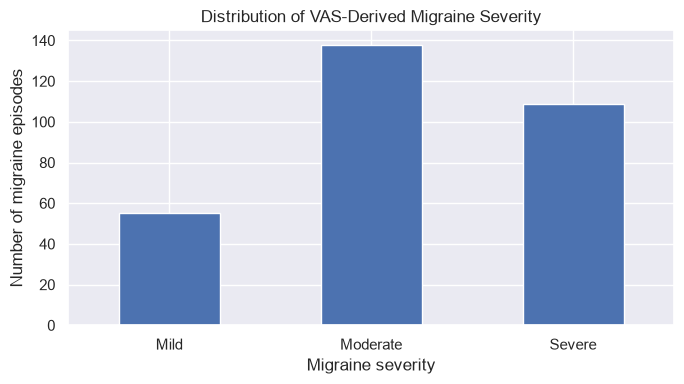

In [11]:
figure, axis = plt.subplots(figsize=(7, 4))

severity_counts.plot(
    kind="bar",
    ax=axis,
)

axis.set_title("Distribution of VAS-Derived Migraine Severity")
axis.set_xlabel("Migraine severity")
axis.set_ylabel("Number of migraine episodes")
axis.tick_params(axis="x", rotation=0)

figure.tight_layout()
plt.show()

### 2.2 Missing Data Assessment

Missing values were addressed during the data-cleaning phase prior to EDA. The final modeling dataset was reviewed to confirm that the variables included in the current analysis do not contain unresolved missing values.

In [12]:
# Missing values sanity check
missing_values = model_df.isna().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

## 3. Physiological Factors and Migraine Severity — RQ2
### ***RQ2: Which physiological factors are most predictive of migraine severity?***

### 3.1 Physiological Factor Prevalence

Calculate the prevalence of each binary physiological factor within Mild, Moderate, and Severe migraine episodes to identify patterns that may be associated with increasing migraine severity.

In [13]:
physiological_prevalence = create_binary_prevalence_table(
    data = model_df,
    variables = PHYSIOLOGICAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

physiological_prevalence.head(15)

,Feature,Severity,Percent Present
0,Preventive Medication Use,Mild,36.36
1,Preventive Medication Use,Moderate,54.35
2,Preventive Medication Use,Severe,52.29
3,Internal Factor: Stress,Mild,32.73
4,Internal Factor: Stress,Moderate,44.20
5,Internal Factor: Stress,Severe,30.28
6,Internal Factor: Oversleeping,Mild,3.64
7,Internal Factor: Oversleeping,Moderate,1.45
8,Internal Factor: Oversleeping,Severe,1.83
9,Internal Factor: Sleep Deprivation,Mild,20.00


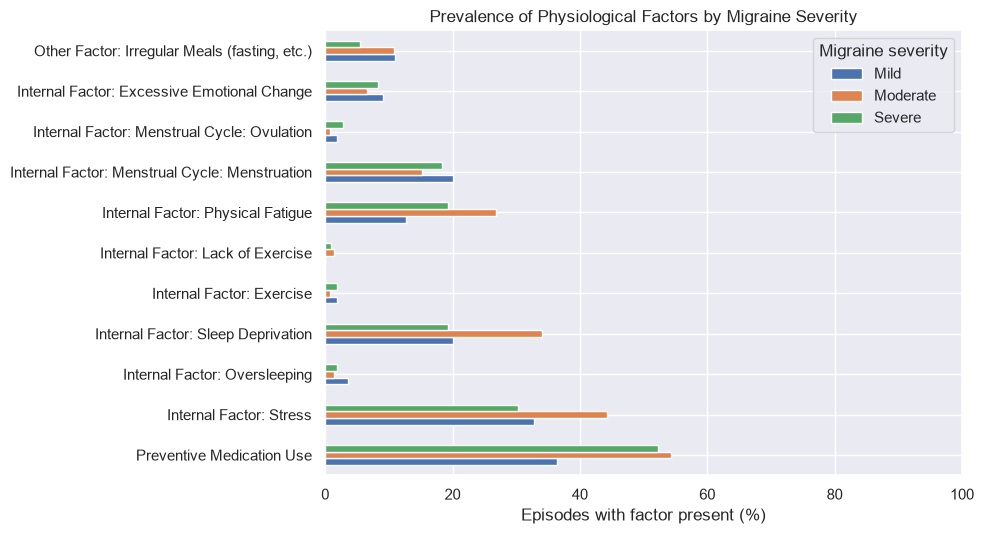

,Mild,Moderate,Severe
Feature,,,
Preventive Medication Use,36.36,54.35,52.29
Internal Factor: Stress,32.73,44.20,30.28
Internal Factor: Oversleeping,3.64,1.45,1.83
Internal Factor: Sleep Deprivation,20.00,34.06,19.27
Internal Factor: Exercise,1.82,0.72,1.83
Internal Factor: Lack of Exercise,0.00,1.45,0.92
Internal Factor: Physical Fatigue,12.73,26.81,19.27
Internal Factor: Menstrual Cycle: Menstruation,20.00,15.22,18.35
Internal Factor: Menstrual Cycle: Ovulation,1.82,0.72,2.75


In [14]:
physiological_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = PHYSIOLOGICAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "Physiological Factors",
)

physiological_prevalence_wide.round(2)

### 3.2 Exercise Participation by Migraine Severity

Examine the distribution of the categorical `Total Exercise` variable across migraine severity levels. Percentages are calculated within each severity category to compare exercise participation patterns.

In [15]:
total_exercise_table = create_ordinal_percentage_table(
    data = model_df,
    variable = "Total Exercise",
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

total_exercise_table.round(2)

Total Exercise,0,1,2
Severity_VAS,,,
Mild,1.82,14.55,83.64
Moderate,1.45,15.94,82.61
Severe,3.67,10.09,86.24


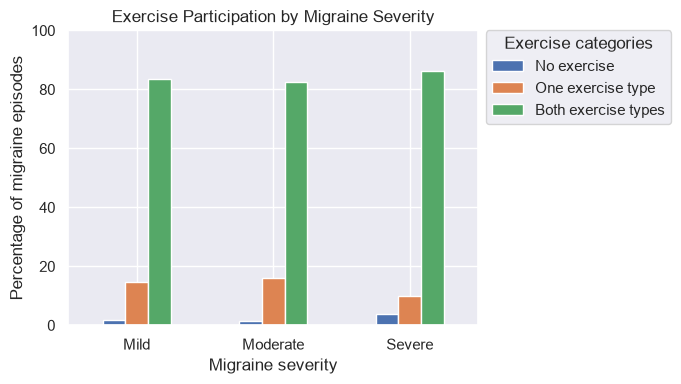

In [16]:
figure, axis = plt.subplots(figsize=(7, 4))

total_exercise_table.plot(
    kind = "bar",
    ax = axis,
)

axis.set_title("Exercise Participation by Migraine Severity")
axis.set_xlabel("Migraine severity")
axis.set_ylabel("Percentage of migraine episodes")
axis.set_ylim(0, 100)
axis.tick_params(axis="x", rotation=0)

axis.legend(
    title = "Exercise categories",
    labels = [
        "No exercise",
        "One exercise type",
        "Both exercise types",
    ],
    loc = "upper left",  # Anchor point of the legend box
    bbox_to_anchor=(1.02, 1),  # Places legend just outside the right boundary (x=1.02, y=1)
    borderaxespad=0
)

figure.tight_layout()
plt.show()

## 4. Environmental Factors and Migraine Severity — RQ3
### ***RQ3: Which environmental factors are most predictive of migraine severity?***

### 4.1 Environmental Factor Prevalence

Calculate the prevalence of binary environmental factors within each migraine severity category and visualize differences across Mild, Moderate, and Severe episodes.

In [17]:
environmental_prevalence = create_binary_prevalence_table(
    data = model_df,
    variables = ENVIRONMENTAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

environmental_prevalence

,Feature,Severity,Percent Present
0,External Factor: Excessive Sunlight,Mild,0.00
1,External Factor: Excessive Sunlight,Moderate,0.72
2,External Factor: Excessive Sunlight,Severe,2.75
3,External Factor: Noise,Mild,1.82
4,External Factor: Noise,Moderate,10.14
5,External Factor: Noise,Severe,8.26
6,External Factor: Inappropriate Lighting,Mild,0.00
7,External Factor: Inappropriate Lighting,Moderate,0.72
8,External Factor: Inappropriate Lighting,Severe,2.75
9,"External Factor: Specific Smell (cosmetics, pe...",Mild,3.64


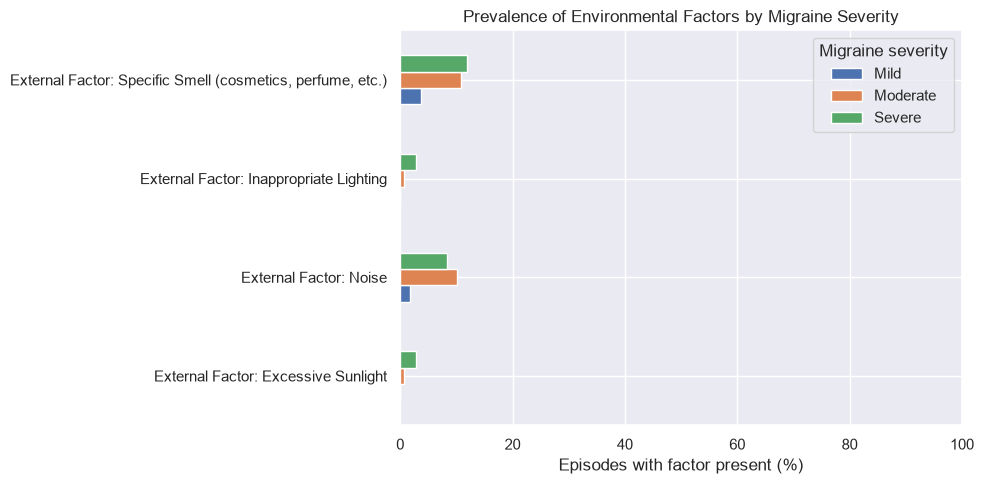

,Mild,Moderate,Severe
Feature,,,
External Factor: Excessive Sunlight,0.00,0.72,2.75
External Factor: Noise,1.82,10.14,8.26
External Factor: Inappropriate Lighting,0.00,0.72,2.75
"External Factor: Specific Smell (cosmetics, perfume, etc.)",3.64,10.87,11.93


In [18]:
binary_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = ENVIRONMENTAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "Environmental Factors",
)

binary_prevalence_wide.round(2)

### 4.2 Time of Day and Migraine Severity

In [19]:
TEMPORAL_FEATURES

model_df[TEMPORAL_FEATURES].head()

,Start_Hour,Time_of_Day
0,10.0,Morning
1,11.0,Morning
2,11.0,Morning
3,20.0,Evening
4,8.0,Morning


#### 4.2.1 Time-of-Day Distribution by Migraine Severity

Examine the distribution of migraine onset across time-of-day categories for Mild, Moderate, and Severe migraine episodes. Percentages are calculated within each severity category to identify potential differences in migraine onset timing across severity levels.

In [20]:
# Calculate time of day percentages within each migraine severity category
time_of_day_table = pd.crosstab(
    model_df[TARGET],
    model_df["Time_of_Day"],
    normalize = "index"
).mul(100).round(2)

# Reorder severity categories to match SEVERITY_ORDER
time_of_day_table = time_of_day_table.reindex(SEVERITY_ORDER)

time_of_day_table


Time_of_Day,Afternoon,Evening,Morning,Night
Severity_VAS,,,,
Mild,30.91,16.36,38.18,14.55
Moderate,22.46,7.25,53.62,16.67
Severe,20.18,6.42,55.96,17.43


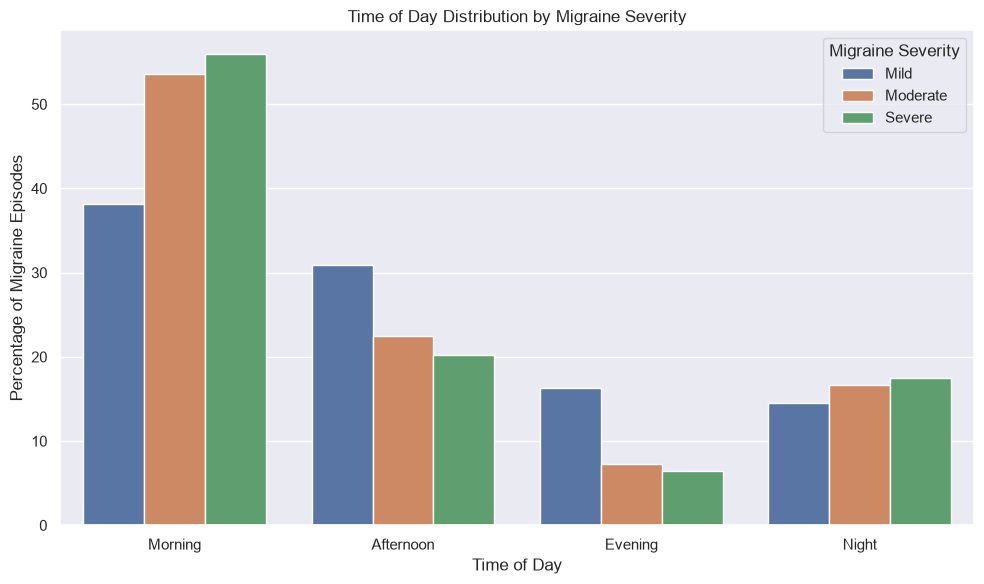

In [21]:
# Define the custom order for the x-axis
TIME_ORDER = ["Morning", "Afternoon", "Evening", "Night"]  # Adjust capitalization if needed to match your dataset values

# Plot time-of-day distribution by migraine severity
time_of_day_plot = (
    time_of_day_table
    .reset_index()
    .melt(
        id_vars=TARGET,
        var_name="Time_of_Day",
        value_name="Percentage"
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=time_of_day_plot,
    x="Time_of_Day",
    y="Percentage",
    hue=TARGET,
    hue_order=SEVERITY_ORDER,
    order=TIME_ORDER  # Ensure bars are ordered by defined time of day sequence
)

plt.title("Time of Day Distribution by Migraine Severity")
plt.xlabel("Time of Day")
plt.ylabel("Percentage of Migraine Episodes")
plt.legend(title="Migraine Severity")
plt.tight_layout()
plt.show()

#### 4.2.2 Migraine Start Hour by Severity

Examine the distribution of migraine onset hour across severity categories to determine whether onset timing differs among Mild, Moderate, and Severe migraine episodes.

In [22]:
# Summarize migraine onset hour by severity category
from pickle import TRUE


start_hour_summary = (
    model_df
    .groupby(TARGET, observed = TRUE)["Start_Hour"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(SEVERITY_ORDER)
    .round(2)
)

start_hour_summary

,count,mean,median,std,min,max
Severity_VAS,,,,,,
Mild,55,11.84,12.0,5.70,0.0,22.0
Moderate,138,9.51,9.0,5.03,0.0,21.0
Severe,109,9.09,9.0,5.06,0.0,23.0


#### 4.2.3 Association Between Time of Day and Migraine Severity

Evaluate whether migraine onset time-of-day category is associated with migraine severity using a chi-square test of independence. Cramér's V is calculated to quantify the strength of the association.

In [23]:
# Analyze association between time of day and migraine severity
time_of_day_results, time_of_day_crosstabs = (
    analyze_categorical_associations(
        data=model_df,
        variable="Time_of_Day",
        target=TARGET,
        target_order=SEVERITY_ORDER,
    )
)

# Display categorical association results
print("Statistical Results")
display(pd.DataFrame([time_of_day_results]))

print("Observed Counts")
display(time_of_day_crosstabs["counts"])

print("Row Percentages")
display(time_of_day_crosstabs["row_percentages"])

print("Expected Counts")
display(time_of_day_crosstabs["expected_counts"])

Statistical Results


,Feature,N,Chi-Square,Degrees of Freedom,P-Value,Cramers V,Minimum Expected Count,Expected Counts Below 5,Expected Counts Below 1,Proportion Expected Below 5,Assumptions Met,Status
0,Time_of_Day,302,9.228828,6,0.161112,0.12361,4.735099,1,0,0.083333,True,Test completed


Observed Counts


Time_of_Day,Afternoon,Evening,Morning,Night
Severity_VAS,,,,
Mild,17,9,21,8
Moderate,31,10,74,23
Severe,22,7,61,19


Row Percentages


Time_of_Day,Afternoon,Evening,Morning,Night
Severity_VAS,,,,
Mild,30.91,16.36,38.18,14.55
Moderate,22.46,7.25,53.62,16.67
Severe,20.18,6.42,55.96,17.43


Expected Counts


Time_of_Day,Afternoon,Evening,Morning,Night
Severity_VAS,,,,
Mild,12.748344,4.735099,28.410596,9.105960
Moderate,31.986755,11.880795,71.284768,22.847682
Severe,25.264901,9.384106,56.304636,18.046358


### **DEPEND ON API**
### 4.3 Historical Weather Data Overview
### 4.4 Weather Variables by Migraine Severity
### 4.5 Weather Changes and Migraine Severity
### 4.6 Environmental Factor Associations with Migraine Severity

## 5. Lifestyle and Behavioral Factors

### 5.1 Lifestyle Factor Prevalence

Calculate the prevalence of binary lifestyle factors within each migraine severity category and compare their distributions across severity levels.

In [24]:
lifestyle_prevalence = create_binary_prevalence_table(
    data = model_df,
    variables = LIFESTYLE_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

lifestyle_prevalence

,Feature,Severity,Percent Present
0,Other Factor: Excessive Alcohol,Mild,5.45
1,Other Factor: Excessive Alcohol,Moderate,7.25
2,Other Factor: Excessive Alcohol,Severe,7.34
3,Other Factor: Overeating,Mild,5.45
4,Other Factor: Overeating,Moderate,2.90
5,Other Factor: Overeating,Severe,6.42
6,Other Factor: Excessive Caffeine,Mild,0.00
7,Other Factor: Excessive Caffeine,Moderate,0.72
8,Other Factor: Excessive Caffeine,Severe,4.59
9,Other Factor: Excessive Smoking,Mild,1.82


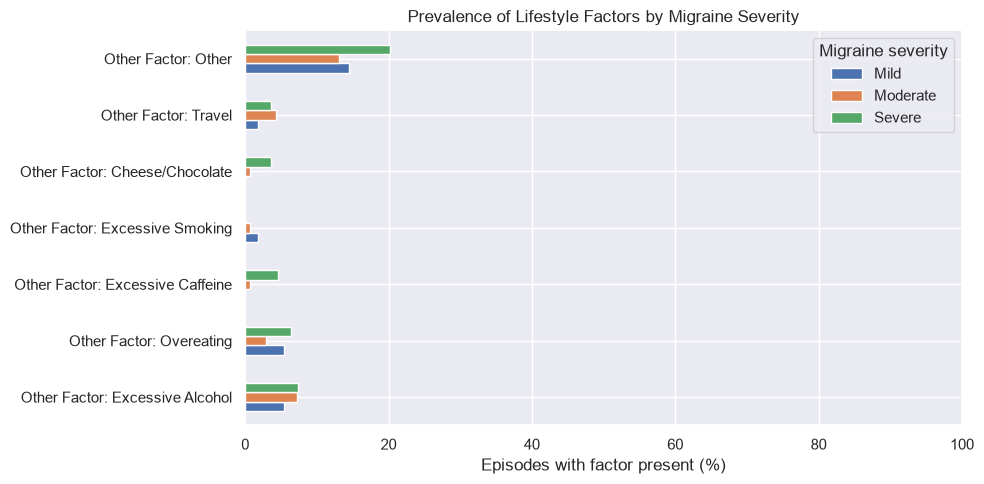

,Mild,Moderate,Severe
Feature,,,
Other Factor: Excessive Alcohol,5.45,7.25,7.34
Other Factor: Overeating,5.45,2.90,6.42
Other Factor: Excessive Caffeine,0.00,0.72,4.59
Other Factor: Excessive Smoking,1.82,0.72,0.00
Other Factor: Cheese/Chocolate,0.00,0.72,3.67
Other Factor: Travel,1.82,4.35,3.67
Other Factor: Other,14.55,13.04,20.18


In [25]:
binary_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = LIFESTYLE_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "Lifestyle Factors",
)

binary_prevalence_wide.round(2)

## 6. Overall Predictor Associations — RQ1
### ***RQ1: To what extent can migraine severity be predicted using physiological and environmental factors?***

This exploratory analysis examines preliminary relationships between the candidate predictors and migraine severity. Predictive performance for RQ1 will be formally evaluated during model development.

### 6.1 Comparison of All Binary Predictors

Visualize physiological, environmental, and lifestyle binary predictors together to identify broader prevalence patterns across migraine severity categories.

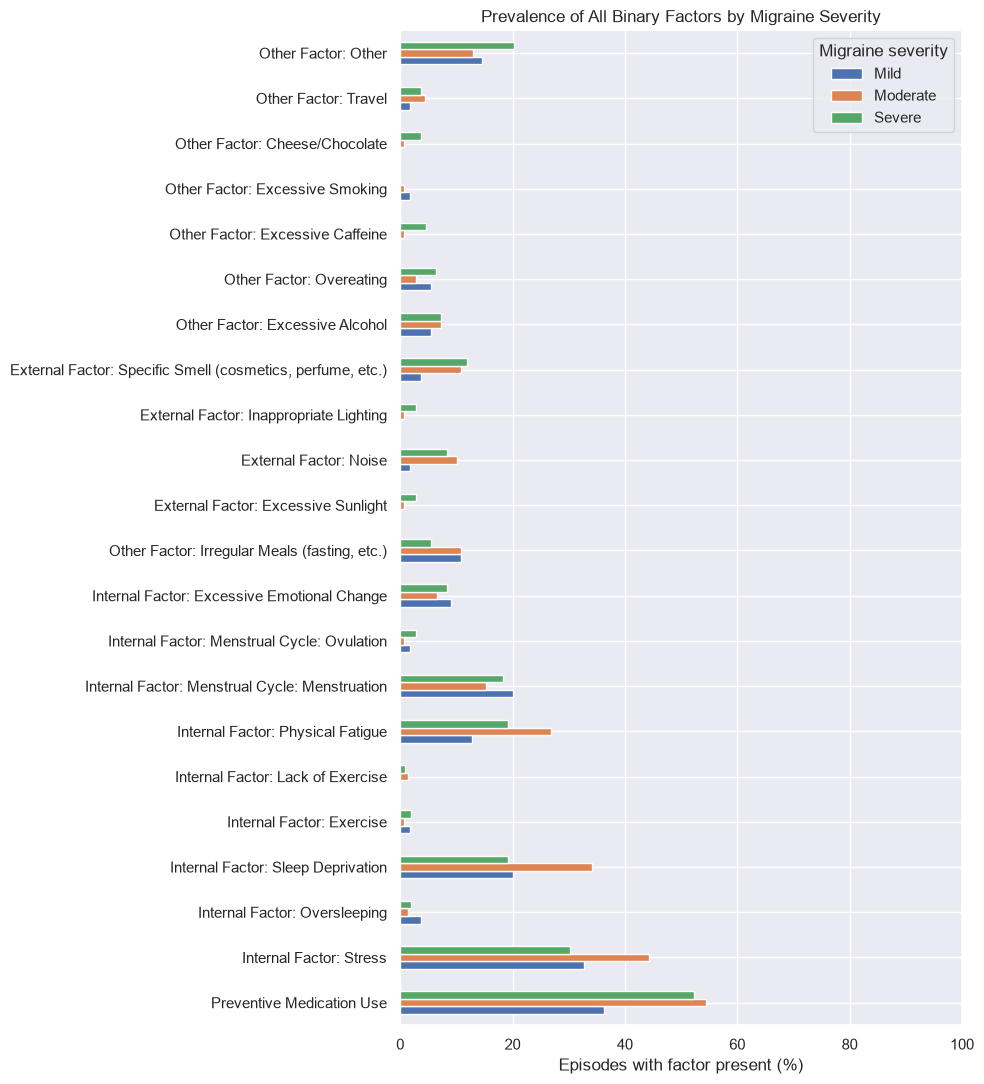

,Mild,Moderate,Severe
Feature,,,
Preventive Medication Use,36.36,54.35,52.29
Internal Factor: Stress,32.73,44.20,30.28
Internal Factor: Oversleeping,3.64,1.45,1.83
Internal Factor: Sleep Deprivation,20.00,34.06,19.27
Internal Factor: Exercise,1.82,0.72,1.83
Internal Factor: Lack of Exercise,0.00,1.45,0.92
Internal Factor: Physical Fatigue,12.73,26.81,19.27
Internal Factor: Menstrual Cycle: Menstruation,20.00,15.22,18.35
Internal Factor: Menstrual Cycle: Ovulation,1.82,0.72,2.75


In [26]:
binary_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = PHYSIOLOGICAL_BINARY_FEATURES + ENVIRONMENTAL_BINARY_FEATURES + LIFESTYLE_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "All Binary Factors",
)

binary_prevalence_wide.round(2)

### 6.2 Binary Feature Associations with Migraine Severity

Evaluate the association between each physiological, environmental, and lifestyle binary feature and migraine severity using chi-square tests and Cramér's V effect sizes. Apply the Benjamini-Hochberg procedure to control the false discovery rate across multiple comparisons.

In [27]:
all_binary_features = (
    PHYSIOLOGICAL_BINARY_FEATURES
    + ENVIRONMENTAL_BINARY_FEATURES
    + LIFESTYLE_BINARY_FEATURES
)

# Analyze associations between binary features and migraine severity
binary_test_results, binary_crosstabs = analyze_binary_associations(
    data = model_df,
    variables = all_binary_features,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
)

# Add Benjamini-Hochberg correction to the p-values
binary_test_results = add_benjamini_hochberg_correction(binary_test_results)

binary_test_results = (
    binary_test_results
    .sort_values(
        ["Adjusted P-Value", "P-Value"],
        na_position="last",
    )
    .reset_index(drop=True)
)

binary_test_results

,Feature,N,Chi-Square,Degrees of Freedom,P-Value,Cramers V,Minimum Expected Count,Expected Counts Below 5,Assumptions Met,Status,Adjusted P-Value,Significant After FDR
0,Internal Factor: Sleep Deprivation,302,8.218844,2,0.016417,0.164969,14.387417,0,True,Test completed,0.337933,False
1,Other Factor: Excessive Caffeine,302,6.028855,2,0.049074,0.141291,1.092715,3,False,Test completed,0.337933,False
2,Internal Factor: Stress,302,5.610585,2,0.060489,0.136301,20.397351,0,True,Test completed,0.337933,False
3,Preventive Medication Use,302,5.350735,2,0.068882,0.133108,27.317881,0,True,Test completed,0.337933,False
4,Internal Factor: Physical Fatigue,302,5.133026,2,0.076803,0.130372,11.837748,0,True,Test completed,0.337933,False
5,Other Factor: Cheese/Chocolate,302,4.376190,2,0.112130,0.120377,0.910596,3,False,Test completed,0.411144,False
6,External Factor: Noise,302,3.749673,2,0.153380,0.111428,4.370861,1,True,Test completed,0.482051,False
7,"External Factor: Specific Smell (cosmetics, pe...",302,3.056768,2,0.216886,0.100607,5.463576,0,True,Test completed,0.537552,False
8,External Factor: Excessive Sunlight,302,2.818376,2,0.244342,0.096604,0.728477,3,False,Test completed,0.537552,False
9,External Factor: Inappropriate Lighting,302,2.818376,2,0.244342,0.096604,0.728477,3,False,Test completed,0.537552,False


### 6.3 Summary of Binary Feature Association Results

Organize the binary association results by feature group and summarize sample size, chi-square statistics, raw and adjusted p-values, Cramér's V effect sizes, test assumptions, and statistical significance after FDR correction.

In [28]:
feature_to_group = {
    feature: group_name
    for group_name, feature_list in {
        "Physiological": PHYSIOLOGICAL_BINARY_FEATURES,
        "Environmental": ENVIRONMENTAL_BINARY_FEATURES,
        "Lifestyle": LIFESTYLE_BINARY_FEATURES,
    }.items()
    for feature in feature_list
}

if "Feature Group" not in binary_test_results.columns:
    binary_test_results.insert(
        1,
        "Feature Group",
        binary_test_results["Feature"].map(
            feature_to_group
        ),
    )
else:
    binary_test_results["Feature Group"] = binary_test_results["Feature"].map(feature_to_group)

binary_test_results[
    [
        "Feature",
        "Feature Group",
        "N",
        "Chi-Square",
        "P-Value",
        "Adjusted P-Value",
        "Cramers V",
        "Assumptions Met",
        "Significant After FDR",
    ]
]

,Feature,Feature Group,N,Chi-Square,P-Value,Adjusted P-Value,Cramers V,Assumptions Met,Significant After FDR
0,Internal Factor: Sleep Deprivation,Physiological,302,8.218844,0.016417,0.337933,0.164969,True,False
1,Other Factor: Excessive Caffeine,Lifestyle,302,6.028855,0.049074,0.337933,0.141291,False,False
2,Internal Factor: Stress,Physiological,302,5.610585,0.060489,0.337933,0.136301,True,False
3,Preventive Medication Use,Physiological,302,5.350735,0.068882,0.337933,0.133108,True,False
4,Internal Factor: Physical Fatigue,Physiological,302,5.133026,0.076803,0.337933,0.130372,True,False
5,Other Factor: Cheese/Chocolate,Lifestyle,302,4.376190,0.112130,0.411144,0.120377,False,False
6,External Factor: Noise,Environmental,302,3.749673,0.153380,0.482051,0.111428,True,False
7,"External Factor: Specific Smell (cosmetics, pe...",Environmental,302,3.056768,0.216886,0.537552,0.100607,True,False
8,External Factor: Excessive Sunlight,Environmental,302,2.818376,0.244342,0.537552,0.096604,False,False
9,External Factor: Inappropriate Lighting,Environmental,302,2.818376,0.244342,0.537552,0.096604,False,False


### 6.4 Individual Binary Feature Examination

Examine the distribution of a selected binary feature across migraine severity categories. This analysis can be used to investigate individual predictors in greater detail when patterns identified during the broader prevalence or association analyses warrant further examination.

In [29]:
# Select an individual feature for closer examination
feature = "Internal Factor: Stress"

display(binary_crosstabs[feature]["counts"])
display(binary_crosstabs[feature]["row_percentages"])
display(binary_crosstabs[feature]["expected_counts"])

Internal Factor: Stress,0,1
Severity_VAS,,
Mild,37,18
Moderate,77,61
Severe,76,33


Internal Factor: Stress,0,1
Severity_VAS,,
Mild,67.27,32.73
Moderate,55.80,44.20
Severe,69.72,30.28


Internal Factor: Stress,0,1
Severity_VAS,,
Mild,34.602649,20.397351
Moderate,86.821192,51.178808
Severe,68.576159,40.423841


## 7. Relationships Among Predictors — Supporting RQ5
### ***RQ5: What is the relative contribution of physiological versus environmental factors in predicting migraine severity?***

Examine relationships among candidate predictors to identify potentially redundant or strongly associated features prior to feature engineering and model development. These exploratory analyses characterize the structure of the predictor set but do not directly measure predictive contribution, which will be evaluated during model comparison.

### 7.1 Relationships Among Binary Predictors

Evaluate pairwise associations among binary physiological, environmental, and lifestyle predictors using the phi coefficient. Strong associations may indicate that predictors contain overlapping information and should be considered during feature engineering and model interpretation.

In [ ]:
# Calculate pairwise phi coefficients among all binary features
phi_matrix = calculate_phi_matrix(
    data = model_df,
    variables = all_binary_features,
)

phi_matrix.round(2)

,Preventive Medication Use,Internal Factor: Stress,Internal Factor: Oversleeping,Internal Factor: Sleep Deprivation,Internal Factor: Exercise,Internal Factor: Lack of Exercise,Internal Factor: Physical Fatigue,Internal Factor: Menstrual Cycle: Menstruation,Internal Factor: Menstrual Cycle: Ovulation,Internal Factor: Excessive Emotional Change,...,External Factor: Noise,External Factor: Inappropriate Lighting,"External Factor: Specific Smell (cosmetics, perfume, etc.)",Other Factor: Excessive Alcohol,Other Factor: Overeating,Other Factor: Excessive Caffeine,Other Factor: Excessive Smoking,Other Factor: Cheese/Chocolate,Other Factor: Travel,Other Factor: Other
Preventive Medication Use,1.00,-0.11,0.05,0.09,0.06,0.03,-0.03,-0.04,-0.08,-0.09,...,0.10,-0.12,0.26,-0.15,-0.13,-0.14,0.08,0.13,0.05,0.12
Internal Factor: Stress,-0.11,1.00,0.09,0.15,-0.03,0.06,0.15,-0.10,-0.10,0.24,...,-0.02,0.09,-0.07,-0.10,-0.07,0.04,0.02,-0.10,-0.08,-0.09
Internal Factor: Oversleeping,0.05,0.09,1.00,-0.08,-0.02,-0.01,-0.07,-0.00,-0.02,-0.04,...,-0.04,-0.02,-0.05,-0.04,-0.03,-0.02,-0.01,-0.02,-0.03,0.00
Internal Factor: Sleep Deprivation,0.09,0.15,-0.08,1.00,-0.07,0.09,0.29,-0.09,-0.08,0.03,...,0.24,-0.00,0.31,-0.10,-0.02,-0.03,0.14,0.22,0.09,-0.07
Internal Factor: Exercise,0.06,-0.03,-0.02,-0.07,1.00,-0.01,0.08,0.02,-0.02,-0.03,...,-0.03,-0.01,-0.04,-0.03,-0.03,-0.02,-0.01,-0.02,-0.02,0.03
Internal Factor: Lack of Exercise,0.03,0.06,-0.01,0.09,-0.01,1.00,0.11,-0.05,-0.01,-0.03,...,0.09,-0.01,-0.03,-0.03,-0.02,-0.01,-0.01,-0.01,0.16,-0.04
Internal Factor: Physical Fatigue,-0.03,0.15,-0.07,0.29,0.08,0.11,1.00,-0.15,-0.07,-0.03,...,0.14,0.01,0.07,-0.05,-0.08,-0.02,0.06,0.06,0.07,0.01
Internal Factor: Menstrual Cycle: Menstruation,-0.04,-0.10,-0.00,-0.09,0.02,-0.05,-0.15,1.00,-0.06,-0.06,...,-0.07,-0.05,-0.03,-0.02,0.02,0.12,-0.04,0.08,-0.09,-0.17
Internal Factor: Menstrual Cycle: Ovulation,-0.08,-0.10,-0.02,-0.08,-0.02,-0.01,-0.07,-0.06,1.00,-0.04,...,-0.04,0.21,-0.04,-0.04,-0.03,-0.02,-0.01,-0.02,-0.03,0.01
Internal Factor: Excessive Emotional Change,-0.09,0.24,-0.04,0.03,-0.03,-0.03,-0.03,-0.06,-0.04,1.00,...,0.01,-0.03,0.07,-0.08,-0.00,-0.04,-0.02,0.06,0.01,-0.02


### 7.2 Visualize the Relationships

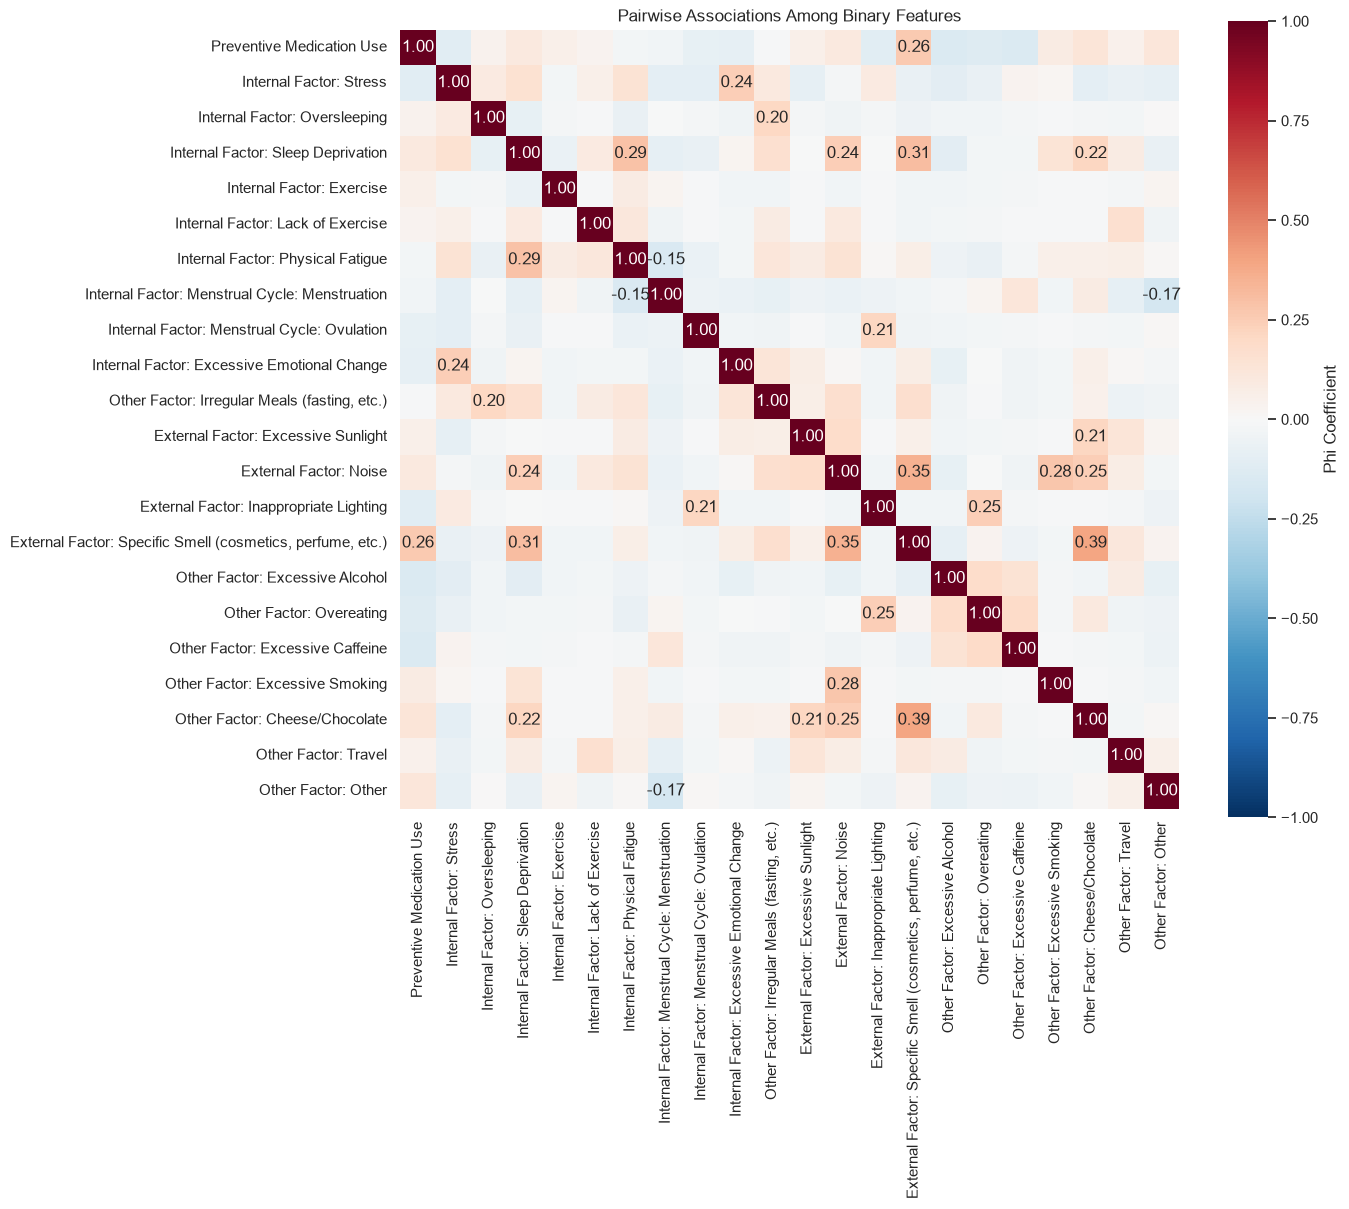

In [ ]:
# Create custom annotation labels
# Show values where the absolute phi coefficient is >= 0.20 and <= -0.15, otherwise leave the cell blank
annot_labels = np.where(
    (phi_matrix >= 0.20) | (phi_matrix <= -0.15),
    np.vectorize(lambda x: f"{x:.2f}")(phi_matrix),
    ""
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    phi_matrix,
    annot=annot_labels,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Phi Coefficient"},
    square=True
)

plt.title("Pairwise Associations Among Binary Features")
plt.tight_layout()
plt.show()

### 7.3 Strongest Associations Among Binary Predictors

Identify predictor pairs with the strongest absolute phi coefficients to highlight potentially redundant or closely related variables.

In [37]:
# Extract unique predictor pairs
upper_triangle = np.triu(
    np.ones(phi_matrix.shape),
    k=1
).astype(bool)

phi_pairs = (
    phi_matrix
    .where(upper_triangle)
    .stack()
    .reset_index()
)

phi_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Phi"
]

phi_pairs["Absolute Phi"] = phi_pairs["Phi"].abs()

phi_pairs = phi_pairs.sort_values(
    "Absolute Phi",
    ascending=False
)

phi_pairs.head(15)

,Feature 1,Feature 2,Phi,Absolute Phi
327,"External Factor: Specific Smell (cosmetics, pe...",Other Factor: Cheese/Chocolate,0.390688,0.390688
278,External Factor: Noise,"External Factor: Specific Smell (cosmetics, pe...",0.352642,0.352642
80,Internal Factor: Sleep Deprivation,"External Factor: Specific Smell (cosmetics, pe...",0.306094,0.306094
72,Internal Factor: Sleep Deprivation,Internal Factor: Physical Fatigue,0.293251,0.293251
282,External Factor: Noise,Other Factor: Excessive Smoking,0.277889,0.277889
14,Preventive Medication Use,"External Factor: Specific Smell (cosmetics, pe...",0.263491,0.263491
302,External Factor: Inappropriate Lighting,Other Factor: Overeating,0.249967,0.249967
283,External Factor: Noise,Other Factor: Cheese/Chocolate,0.249707,0.249707
31,Internal Factor: Stress,Internal Factor: Excessive Emotional Change,0.244745,0.244745
78,Internal Factor: Sleep Deprivation,External Factor: Noise,0.242953,0.242953


## **NEEDS API**
### 7.4 Correlations Among Continuous Weather Predictors
### 7.5 Relationships Between Weather and Diary Predictors

## 8. EDA Summary

### 8.1 Key Physiological Patterns — RQ2

### 8.2 Key Environmental Patterns — RQ3

### 8.3 Implications for Feature Engineering

### 8.4 Implications for Modeling